# LEARNING OBJECTIVE

This notebook demonstrates how to find (by separation of variables and Fourier series), plot, and interpret the unidirectional flow solution for steady Poiseuille flow in a 3D duct.

# PRELIMINARIES

[run the next cell to setup Python environment customizations and load packages]

In [1]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# ploting customizations
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# for animations
from matplotlib import animation, rc
from IPython.display import HTML

# numerics
import numpy as np
from scipy.optimize import fsolve

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

# FLOW IN A 3D DUCT WITH RECTANGULAR CROSS SECTION

## Problem statement

In this notebook, I present an alternative (to Panton's section 11.2) analysis of the unidirection flow in a rectangular tube. My approach actually follows Henrik Bruus' [book](http://homes.nano.aau.dk/lg/Lab-on-Chip2008_files/HenrikBruus_Microfluidics%20lectures.pdf) (section 2.4.5).

Let $\underline{v}=\big(v(y,z,t),0,0\big)$ be our unidirectional flow profile. The flow domain is the box defined by $\{(x,y,z) \;|\; 0\le x \le L,\; -w/2 \le y \le w/2,\; 0\le z \le h\}$ (see diagram below).

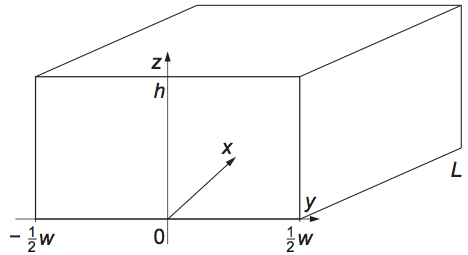

## Governing equations

First, let us use [SymPy](https://docs.sympy.org/latest/tutorial/index.html) to verify that $\underline{v}\cdot\nabla\underline{v}=\underline{0}$ for this flow.

grad v is


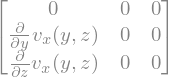

In [2]:
x, y, z = sp.symbols('x y z')
v_x = sp.Function('v_x')(y,z)

velfield = [v_x, 0, 0]

# this is one convenient way to calculate the gradient of a vector,
# sort of as a "Jacobian"
gradv = sp.derive_by_array(velfield, [x, y, z]).tomatrix()

print('grad v is')
gradv

In [3]:
# check v*grad(v) = 0, realizing it is grad(v)^t * v
# when coded up as a right vector-matrix multiplication
print('v * grad v is')
gradv.transpose()*sp.Matrix(velfield)

v * grad v is


**Detour**: recall that $\nabla^2\underline{v}=\nabla\cdot\nabla\underline{v}$ by definition. Also (index notation excercise), the divergence of a tensor can be reformulated as $\nabla\cdot\underline{\underline{T}}=\partial_jT_{ji} = \partial_k T_{ji} \delta_{kj} = \nabla\underline{\underline{T}}:\underline{\underline{\delta}}$, where $\delta$ is the Kronecker symbol/indentity tensor. So, $\nabla^2\underline{v} = (\nabla\nabla\underline{v}):\underline{\underline{\delta}}$. Looks terrible, no? :) But it's true. In index notation, it simply the "double contraction" $\partial_i\partial_iv_j$, which we recognize. This identity gives a way to compute the Laplacian as "div grad" in SymPy. 

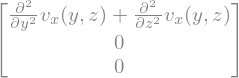

In [4]:
# gradient of the gradient of the velocity
gradgradv = sp.derive_by_array(gradv, (x, y, z));
#sp.pprint(gradgradv)

# double contraction with the identity across 1st (0) and 2nd (1) indices
laplv = sp.Matrix(sp.tensorcontraction(gradgradv, (0, 1)))
laplv

Thus, for this flow, the incompressible Navier&ndash;Stokes (iNS) equations, reduce to
\begin{align*}
    \rho\frac{\partial v}{\partial t} &= -\frac{\partial p}{\partial x} + \mu\left( \frac{\partial^2 v}{\partial y^2} + \frac{\partial^2 v}{\partial z^2} \right),\\
    0 &= -\frac{\partial p}{\partial y},\\
    0 &= -\frac{\partial p}{\partial z}.
\end{align*}
Thus, $p=p(x)$ only, and $-\partial p/\partial x = -dp/dx = \Delta p/L$ is assumed given/known. The first equation is the sought-after  partial differential equation (PDE) for $v(y,z,t)$.

### Initial and boundary conditions

Next, we need to specify appropriate boundary conditions (BCs) and initial conditions (ICs). Observe that, by counding the number of spatial derivatives, 2 boundary conditions would be needed in each of $y$ and $z$ because we have two partial derivatives with respect to each in the PDE.

We realize that the fluid cannot slip at the top, bottom, left and right wall of the duct. Those walls are stationary, hence the fluid velocity there must vanish:
$$ 
    v(y=-w/2,z,t) = v(y=+w/2,z,t) = 0,\qquad v(y,z=0,t) = v(y,z=h,t) = 0. 
$$
The initial condition is any function $v_0$ of $y$ and $z$ that we choose to specify:
$$ 
    v(y,z,t=0) = v_0(y,z). 
$$

## Solution by separation of variables

Now, let us assume that the flow is steady, i.e., $v=v(y,z)$ is independent of $t$. Additionally, since $v \ne v(x)$, the longitudinal pressure gradient $-\partial p/\partial x = \Delta p/L$ is a given/known constant. Hence, the _boundary value problem_ (BVP) to be solved is
\begin{align*}
    -\frac{\Delta p}{\mu L} &=  \frac{\partial^2 v}{\partial y^2} + \frac{\partial^2 v}{\partial z^2}, &\quad\text{(PDE)}\\
    v(-w/2,z) &= v(w/2,z) = 0, &\quad\text{(BC1)}\\
    v(y,0) &= v(y,h) = 0, &\quad\text{(BC2)}
\end{align*}

Now, we proceed by _separation of variables_. Unfortunately (PDE) is _inhomogeneous_, so you might immediately see that letting $v(y,z)=f(y)g(z)$ fails to separate the variables. Now what? We could try to transform (PDE) to a homogeneous problem (Panton's approach) or we could try a creative guess.

### A clever idea

We observe that the if the $z$-dependence were ignored, the problem would be that of Poiseuille flow in a slot. So why not try to "guess" some $g(z)$ and try to solve for the "new" $y$ dependence of Poiseuille flow in the duct? Somehow, this makes physical sense.

If $g(z) = \sin\left(n\pi\frac{z}{h}\right)$, then certainly (BC2) is satsified for any integer $n=1,2,3,...$ since $\sin(0) = \sin(n\pi) = 0$. So, let us guess:
$$ 
    v(y,z) = \sum_{n=1}^\infty f_n(y) \sin\left(n\pi\frac{z}{h}\right). 
$$
This guess (or, in mathematical language an [_ansatz_](https://en.wikipedia.org/wiki/Ansatz)) is in the form of a separation of variables solution. Substituting it into (PDE) and the remaining (BC1), we have:
\begin{align*}
    &-\frac{\Delta p}{\mu L} =  \sum_{n=1}^\infty f_n''(y) \sin\left(n\pi\frac{z}{h}\right) + \sum_{n=1}^\infty f_n(y) \sin\left(n\pi\frac{z}{h}\right) \left[-\frac{n^2\pi^2}{h^2}\right] , &\quad\text{(PDE)}\\
    &\sum_{n=1}^\infty f_n(-w/2) \sin\left(n\pi\frac{z}{h}\right) = 0,\quad \sum_{n=1}^\infty f_n(w/2) \sin\left(n\pi\frac{z}{h}\right) = 0. &\quad\text{(BC1)}
\end{align*}

### What is the Fourier sine series of 1?

The transformed version of (PDE) faces one challenge: the left-hand side is not a Fourier series in $\sin\left(n\pi\frac{z}{h}\right)$.

Noting that that $-\Delta p/(\mu L)$ is just a constant, let us compute the Fourier series sine series of of $1$ and multiply it by $-\Delta p/(\mu L)$. To do so, we recall

**Theorem**: The _full_ Fourier series of the odd extension of a function on $z^*\in[-1,1]$ is precisely the the Fourier _sine_ series of the function on $z^*\in[0,1]$.

The odd extension of "1" is simply
$$ 
    1_\mathrm{odd} = \begin{cases} -1 , &\quad -1\le z^* < 0,\\ +1, &\quad 0\le z^*\le +1. \end{cases} 
$$
So:

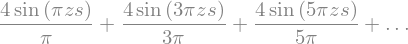

In [5]:
# zstar
zs = sp.symbols('zs')
# use the piecewise function definition from SymPy to define the odd extension:
s = sp.fourier_series(sp.Piecewise((1, zs > 0), (-1, zs < 0), (0, True)), (zs, -1, 1))
s

So the pattern is clear: 
$$ 
    1 = \frac{4}{\pi} \sum_{n \;\text{odd}} \frac{1}{n}\sin\left(n\pi\frac{z}{h}\right),\qquad 0<z<h. 
$$
Hence:
$$
    -\frac{\Delta p}{\mu L}=-\frac{\Delta p}{\mu L}\frac{4}{\pi} \sum_{n \;\text{odd}} \frac{1}{n}\sin\left(n\pi\frac{z}{h}\right).
$$

Substituting into the governing equations:
\begin{align*}
    &-\frac{\Delta p}{\mu L}\frac{4}{\pi} \sum_{n \;\text{odd}} \frac{1}{n}\sin\left(n\pi\frac{z}{h}\right) =  \sum_{n=1}^\infty \left\{ f_n''(y) - \left[-\frac{n^2\pi^2}{h^2}\right] f_n(y) \right\} \sin\left(n\pi\frac{z}{h}\right), &\quad\text{(PDE)}\\
    &\sum_{n=1}^\infty f_n(-w/2) \sin\left(n\pi\frac{z}{h}\right) = 0,\quad \sum_{n=1}^\infty f_n(w/2) \sin\left(n\pi\frac{z}{h}\right) = 0. &\quad\text{(BC1)}
\end{align*}

Now, recall the following **theorem**: if two Fourier sin series converge, then they are equal if and only if all their coefficients agree.

So, we match even/odd terms multiplying the same sines in each of the series on the left- and right-hand sides of (PDE):
\begin{align*}
    0 =  f_n''(y) +  f_n(y) \left[-\frac{n^2\pi^2}{h^2}\right], &\qquad n \text{ even},\\
    -\frac{4\Delta p}{\pi\mu L} \frac{1}{n} =  f_n''(y)  +  f_n(y)  \left[-\frac{n^2\pi^2}{h^2}\right], &\qquad n \text{ odd},
\end{align*}
and (BC1):
$$ 
    f_n(-w/2) = f_n(w/2) = 0,\qquad\text{all } n. 
$$

### Solving for $f_n(y)$

Now it's a matter of solving 2 second-order ODEs with the given BCs. You can verify for yourself that $f_n(y) = 0$ for $n$ even because it is a _homogeneous_ ODE with _homogeneous_ BC, which always yields the trivial solution $f_n(y) = 0$.

Now, we must consider the case of $n$ odd carefully. A particular solution can be guessed by inspection; it must be a constant. To see that, consider
$$ 
    f_{n,\text{particular}}(y) = K \quad\Rightarrow\quad -\frac{4\Delta p}{\pi\mu L} \frac{1}{n} = 0  +  K  \left[-\frac{n^2\pi^2}{h^2}\right] \quad\Rightarrow\quad K = \frac{4h^2\Delta p}{\pi^3\mu L n^3}. 
$$
Now, we must find the homogeneous solution. The characteristic polynomial of the ODE is
$$ 
    r^2 - \frac{n^2\pi^2}{h^2} = 0 \qquad\Rightarrow\qquad  r = \pm \frac{n\pi}{h}, 
$$
hence
$$ 
    f_{n,\text{homogeneous}}(y) = c_1 e^{\frac{n\pi}{h} y} + c_2 e^{-\frac{n\pi}{h} y}. 
$$
Finally, we find that,
$$ 
    f_n(y) = \frac{4h^2\Delta p}{\pi^3\mu L n^3} + c_1 e^{\frac{n\pi}{h} y} + c_2 e^{-\frac{n\pi}{h} y}, \qquad n \text{ odd}. 
$$

Now, we must apply the BCs:
\begin{align*}
    f_n(-w/2) &= \frac{4h^2\Delta p}{\pi^3\mu L n^3} + c_1 e^{-\frac{n\pi w}{2h}} + c_2 e^{\frac{n\pi w}{2h}} = 0,\\
    f_n(w/2) &= \frac{4h^2\Delta p}{\pi^3\mu L n^3} + c_1 e^{\frac{n\pi w}{2h}} + c_2 e^{-\frac{n\pi w}{2h}} = 0.
\end{align*}
These are two algebraic equations in two unknowns ($c_1$ and $c_2$). Subtracting the 2nd from the first and performing some manipulations:
$$ 
    -2 c_1\left( \frac{e^{\frac{n\pi w}{2h}} - e^{-\frac{n\pi w}{2h}}}{2} \right) + 2 c_2 \left( \frac{e^{\frac{n\pi w}{2h}} - e^{-\frac{n\pi w}{2h}}}{2} \right) = 0.
$$
Introducing hyperbolic trigonometric functions:
$$ 
    -2 c_1\cosh\left(\frac{n\pi w}{2h}\right) + 2 c_2 \cosh\left(\frac{n\pi w}{2h}\right) = 0 \qquad\Rightarrow\qquad c_2 = c_1. 
$$
Returning back to the BCs to evaluate $c_1$:
$$ 
    c_1 = -\frac{2h^2\Delta p}{\pi^3\mu L n^3 \cosh\left(\frac{n\pi w}{2h}\right)}. 
$$

Finally,
$$ 
    f_n(y) = \begin{cases} \displaystyle \frac{4h^2\Delta p}{\pi^3\mu L n^3}\left\{1 -\frac{ \cosh\left(\frac{n\pi}{h} y\right)}{\cosh\left(\frac{n\pi}{h} \frac{w}{2}\right)}\right\},&\quad n \text{ odd},\\
    0,&\quad n\text{ even}. \end{cases} 
$$

We can check our ODE solution with SymPy as well:

In [6]:
dp, mu, L, y, h, w = sp.symbols('dp mu L y h w', positive=True)

# we can define n to be specifically a SymPpy integer,
# though it's not important for this calculation.
# I ensured it is positive, to rule n=0, which is not of interest.
n = sp.symbols('n', integer=True, positive=True)

# to ensure f is "callable" with different arguments,
# we don't explicitly write "(y)" at end
f = sp.Function('f')

ode_odd = sp.Eq(f(y).diff(y, y) - n**2*sp.pi**2/h**2*f(y), -4*dp/(n*mu*sp.pi*L))
bcs = { f(-w/2): 0, f(w/2): 0 }
# note that odesol is an *equation* f(y) = rhs, and the rhs is the solution
odesol_odd = sp.dsolve(ode_odd, f(y), ics=bcs)

ode_even = sp.Eq(f(y).diff(y, y) - n**2*sp.pi**2/h**2*f(y), 0)
odesol_even = sp.dsolve(ode_even, f(y), ics=bcs)

for n odd:


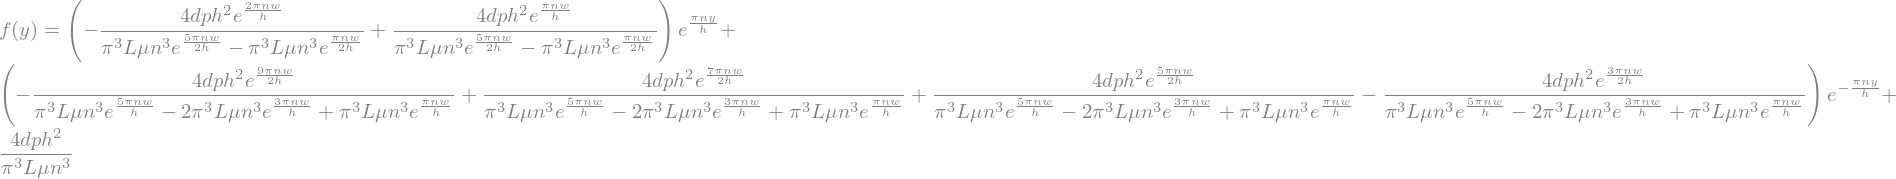

In [7]:
print('for n odd:')
odesol_odd

In [8]:
# the latter is very ugly and I couldn't get it to simplify, 
# but we can check our solution solves the ODE too
my_odesol_odd = 4*h**2*dp/(sp.pi**3*mu*L*n**3)*(1 - sp.cosh(n*sp.pi*y/h)/sp.cosh(n*sp.pi*w/h))
sp.checkodesol(ode_odd, my_odesol_odd)

(True, 0)

In [9]:
print('for n even:')
odesol_even

for n even:


### Final result for the velocity profile $v(y,z)$

Putting it all together:
$$ 
    v(y,z) = \frac{4h^2\Delta p}{\pi^3\mu L}\sum_{n,\text{ odd}}^\infty \frac{1}{n^3} \left\{1 -\frac{ \cosh\left(\frac{n\pi}{h} y\right)}{\cosh\left(\frac{n\pi}{h}\frac{w}{2}\right)}\right\} \sin\left(n\pi\frac{z}{h}\right). 
$$

We can also write down a dimensionless version. Let $\mathcal{V}_\text{char} = \frac{h^2 \Delta p}{2\mu L}$ (should look familiar from Poiseuille flow in a slot!), $v^*=v/\mathcal{V}_\text{char}$, $z^*=z/h$, $y^*=y/w$. Then,
$$ 
    v^*(y^*,z^*) = \frac{8}{\pi^3}\sum_{n,\text{ odd}}^\infty \frac{1}{n^3} \left\{ 1 -\frac{\cosh\left(n\pi \delta y^*\right)}{\cosh\left(n\pi\delta/2\right)} \right\} \sin\left(n\pi z^*\right), 
$$
where $\delta = w/h$ is the _aspect ratio_ of the rectangular cross-section (perpendicular to the flow) of the duct, $\{ (y^*,z^*) \;|\; -1/2 \le y^* \le 1/2,\; 0\le z^* \le h \}$.


# ANALYSIS AND DISCUSSION

## Plots

First, we make some plots of the dimensionless solution.

In [10]:
def vx_eval(delta,y,z):
    # number of terms in series to add ... careful though, because
    # if you pick too many, they become so small that you get
    # numerical underflow errors for large delta
    nmax = 50
    vx = 0
    for n in range(1,nmax,2):
      vx = vx + (8/np.pi**3)*(1/n**3)*(1 - np.cosh(n*np.pi*delta*y)/np.cosh(n*np.pi*delta/2))*np.sin(n*np.pi*z)

    return vx

def contour_plot_func(delta):
    y, z = np.meshgrid( np.linspace(-1/2, 1/2, num=101),
                        np.linspace(0, 1, num=101) )

    vx = vx_eval(delta,y,z)

    fig, ax = plt.subplots(tight_layout=True)
    #ax = plt.axes(projection='3d')
    ax.set_xlabel('$y^*$')
    ax.set_ylabel('$z^*$')

    cs = ax.contourf(y, z, vx, 10)
    #cs = ax.plot_surface(y, vx, z, linewidth=0, antialiased=False)

    # make a colorbar for the ContourSet returned by contourf
    cbar = plt.colorbar(cs)

    cbar.ax.set_ylabel('$v^*(y^*,z^*)$')

    # skew the axis aspect ratio to emphasize the horizontal direction
    # as "long" because we'll consider delta >= 1
    ax.set_aspect(1/1.618)

    plt.show()

interact(contour_plot_func, delta = widgets.FloatSlider(value=1,
                                                        min=0.5,
                                                        max=8.0,
                                                        step=0.5));

interactive(children=(FloatSlider(value=1.0, description='delta', max=8.0, min=0.5, step=0.5), Output()), _dom…

We can also make plots of the profile in the vertical ($y^*=0$) and horizontal ($z^*=1/2$) centerplanes.

In [11]:
def plane_plot_func(delta):
    # grab axes of figure with 2 subplots horizontally arranged
    fig, (ax0, ax1) = plt.subplots(1,2)

    # evaluate z* = 1/2 cross-sectional profile
    y = np.linspace(-1/2, 1/2, num=101)
    vx = vx_eval(delta,y,1/2*np.ones(np.shape(y)))

    # left subplot
    ax0.set_xlabel('$y^*$')
    ax0.set_ylabel('$v^*(y^*,1/2)$')
    ax0.plot(y, vx, color='blue', linewidth=4)
    # add vel arros, skipping every 4th data point for clarity
    ax0.quiver(y[::4], 0*y[::4], 0*vx[::4], vx[::4],
               scale=1., scale_units='xy', color='skyblue', width=0.0125, zorder=2)
    ax0.set(xlim=(-0.51, 0.51), ylim=(0, 0.255))
    #ax0.set_aspect(1)

    # evaluate y* = 0 cross-sectional profile
    z = np.linspace(0, 1, num=101)
    vx = vx_eval(delta,np.zeros(np.shape(z)),z)

    # right subplot
    ax1.set_xlabel('$v^*(0,z^*)$')
    ax1.set_ylabel('$z^*$')
    ax1.plot(vx, z, color='red', linewidth=4)
    # add vel arros, skipping every 4th data point for clarity
    ax1.quiver(0*z[::4], z[::4], vx[::4], 0*vx[::4],
               scale=1., scale_units='xy', color='lightsalmon', width=0.0125, zorder=2)
    ax1.yaxis.tick_right()
    ax1.yaxis.set_label_position("right")
    ax1.set(xlim=(0, 0.255), ylim=(0, 1))

    plt.show()

interact(plane_plot_func, delta = widgets.FloatSlider(value=1,
                                                      min=0.2,
                                                      max=9.0,
                                                      step=0.4));

interactive(children=(FloatSlider(value=1.0, description='delta', max=9.0, min=0.2, step=0.4), Output()), _dom…

## Width and sidewalls effect

**Hypothesis**: The flow along the centerline $y^*=0$ should look like flow in a slot if $w\gg h$ (equivalently, $\delta \gg 1$). But how large should $\delta$ be to have them agree, which means the effect of the lateral sidewalls of the channel at $y=\pm w/2$ is negligible at the centerline?

First, let us evaluate the dimensionless solution at $y^*=0$:
$$ 
    v^*(0,z^*) = \frac{8}{\pi^3} \sum_{n,\text{ odd}}^\infty \frac{1}{n^3} \left\{1 - \frac{1}{\cosh\left(n\pi\delta/2\right)}\right\} \sin\left(n\pi z^*\right). 
$$
Second, we recall that the corresponding dimensionless solution (using the same $\mathcal{V}_\mathrm{char}$ as above) for Poiseulle flow in a slot (with $z$ as the transverse coordinate) is:
$$ 
    v_P^*(z^*) = z^* - \left(z^*\right)^2 . 
$$

Next, we seek a value of $\delta = w/h$ such that $\max_{z^*} |v^*(0,z^*)-v_P^*(z^*)| \simeq 0.01$. This criterion is not unique but is a robust way to compare the profiles, via their maximal velocities. (You could've required that the averaged are within 1%, or any number of other criteria.)

Both velocity profiles, $v^*(0,z^*)$ and $v_P^*(z^*)$, are symmetric (you can show this easily!), hence their maxima occur at $z^*=1/2$. Thus, we seek $w/h$ such that
\begin{align*}
    \max_{z^*} |v^*(0,z^*)-v_P^*(z^*)| &= |v^*(0,1/2) - v_P^*(1/2)|\\
    &= \left|\frac{8}{\pi^3}\sum_{n,\text{ odd}}^\infty \frac{1}{n^3} \left\{1 -\frac{1}{\cosh\left(n\pi\delta/2\right)}\right\} \sin\left(n\pi\frac{1}{2}\right) - \left[\frac{1}{2} - \left( \frac{1}{2} \right)^2 \right] \right|\\
    &= \left| \frac{8}{\pi^3}\sum_{n=1}^\infty \frac{1}{n^3} \left\{1 -\frac{1}{\cosh\left(n\pi\delta/2\right)}\right\} (-1)^{(n-1)/2} - \frac{1}{4} \right| \simeq 0.01.
\end{align*}

We can evaluate this criterion numerically using SciPy:

In [12]:
def vel_diff(delta):
  nmax = 100 # 50 terms should be enough
  sum = 0
  for n in range(1, nmax, 2):
    sum = sum + (1/n**3)*(1-1/np.cosh(n*np.pi*delta/2))*(-1)**((n-1)/2)
  diff = np.abs((8/np.pi**3)*sum - 1/4)

  # substract the RHS of the eq because we'll solve diff - 0.01 = 0 with fsolve
  diff = diff - 0.01
  return diff

initial_guess = 2
print('delta is approximately')
print(fsolve(vel_diff, initial_guess)[0])

delta is approximately
2.5103142893561516


Thus, $\delta = w/h \approx 2.5$ is "sufficiently wide" to neglect sidewalls effects. In other words, if the channel is about $2.5\times$ wider than it is tall, then effect of the horizontal side walls on the centerline velocity is on the order of 1\%, i.e., negligible!

**NOTE**: You should experiment with `nmax` above to ensure that the answer is independent of `nmax`, meaning we took a "sufficient" number of terms in the (technically) infinite series.